<a href="https://colab.research.google.com/github/smriti3003/Forecasting-and-Inventory-Optimization-System/blob/main/AAI501_Final_Project_M5_Retail_Forecasting_Inventory_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AAI-501 Final Team Project
## AI-Driven Retail Demand Forecasting and Inventory Optimization System

**Team Members:** Karthik K, Amita Sirohi, and Smriti Shikha  
**Dataset:** M5 Forecasting – Accuracy  
**Primary scope:** `CA_1` store, `FOODS` category, top 10 products by recent sales  
**Forecast horizon:** 14 days  

### Project Goal

This notebook implements the proposed end-to-end system:

1. Load the original M5 sales, calendar, event/SNAP, and weekly price data.
2. Restrict the analysis to one store/category to keep the project computationally feasible.
3. Perform data quality checks and exploratory analysis.
4. Create leakage-safe lag, rolling, calendar, event, SNAP, and price/promotion features.
5. Use chronological train/validation/test splits.
6. Train and compare:
   - AutoARIMA
   - ETS / Holt–Winters
   - XGBoost regression
7. Evaluate forecasts with MAE, RMSE, MAPE, and a **subset WRMSSE approximation**.
8. Forecast the next 14 days.
9. Convert forecasts into inventory replenishment recommendations using **PuLP**.
10. Run inventory scenario analysis for budget, service level, and demand uncertainty.
11. Produce a concise business/AI-agent style decision brief.
12. Save metrics, forecasts, inventory recommendations, and scenarios for reproducibility.

> **Important metric note:** The official M5 WRMSSE aggregates 42,840 hierarchical series across 12 aggregation levels. To keep this project aligned with the proposal's feasible one-store/category scope, this notebook computes a **bottom-level subset WRMSSE approximation** for the selected products using M5-style scale terms and revenue weights. It is explicitly not presented as the official Kaggle competition score.


## 1. Reproducible Environment Setup

Run this notebook in **Google Colab** or another Python environment with internet access for the easiest setup.  
The installation line uses the libraries named in the project proposal: Nixtla StatsForecast, XGBoost, and PuLP.


In [1]:
# Run once in a fresh Colab/runtime.
%pip install -q statsforecast xgboost pulp

print("Dependencies installed. Restart the runtime only if your environment requests it.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 501.0/501.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.6/348.6 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 2.0 MB/s eta 0:00:00
Dependencies installed. Restart the runtime only if your environment requests it.


## 2. Imports, Configuration, and Random Seeds

In [2]:
from pathlib import Path
import os
import sys
import math
import json
import warnings
import platform
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, AutoETS

import pulp

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

DATA_DIR = Path("data")
OUTPUT_DIR = Path("outputs")
DATA_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

STORE_ID = "CA_1"
CATEGORY_ID = "FOODS"
N_ITEMS = 10
HORIZON = 14
SEASON_LENGTH = 7

TRAIN_END_D = 1913
VAL_END_D = 1927
TEST_END_D = 1941

print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("Store:", STORE_ID)
print("Category:", CATEGORY_ID)
print("Top items:", N_ITEMS)
print("Forecast horizon:", HORIZON, "days")

Python: 3.12.13
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
Store: CA_1
Category: FOODS
Top items: 10
Forecast horizon: 14 days


## 3. Download the Original M5 Dataset

The project uses the same three core files named in the proposal:

- `sales_train_evaluation.csv`
- `calendar.csv`
- `sell_prices.csv`

The notebook first looks for the files in `data/`. If they are missing, it attempts to download an open-access copy from Zenodo. You may instead manually place the Kaggle files in `data/`.


In [3]:
DATA_URLS = {
    "calendar.csv":
        "https://zenodo.org/records/10203108/files/calendar.csv?download=1",
    "sales_train_evaluation.csv":
        "https://zenodo.org/records/10203108/files/sales_train_evaluation.csv?download=1",
    "sell_prices.csv":
        "https://zenodo.org/records/10203108/files/sell_prices.csv?download=1",
}

def download_if_missing(filename, url, data_dir=DATA_DIR):
    path = data_dir / filename
    if path.exists():
        print(f"Found: {path}")
        return path

    print(f"Downloading {filename} ...")
    try:
        urllib.request.urlretrieve(url, path)
        print(f"Saved: {path}")
    except Exception as exc:
        raise RuntimeError(
            f"Could not download {filename}. "
            "Download the M5 Forecasting - Accuracy data from Kaggle or Zenodo "
            f"and place {filename} inside {data_dir.resolve()}."
        ) from exc
    return path

calendar_path = download_if_missing("calendar.csv", DATA_URLS["calendar.csv"])
sales_path = download_if_missing(
    "sales_train_evaluation.csv",
    DATA_URLS["sales_train_evaluation.csv"]
)
prices_path = download_if_missing("sell_prices.csv", DATA_URLS["sell_prices.csv"])

print("\nAll required M5 files are available.")

Saved: data/calendar.csv
Saved: data/sales_train_evaluation.csv
Saved: data/sell_prices.csv

All required M5 files are available.


## 4. Load Calendar Data

In [4]:
calendar = pd.read_csv(calendar_path)
calendar["date"] = pd.to_datetime(calendar["date"])
calendar["d_num"] = calendar["d"].str.replace("d_", "", regex=False).astype(int)

print("Calendar shape:", calendar.shape)
print("Calendar date range:", calendar["date"].min(), "to", calendar["date"].max())
calendar.head()

Calendar shape: (1969, 15)
Calendar date range: 2011-01-29 00:00:00 to 2016-06-19 00:00:00


,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,d_num
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0,1
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0,2
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0,3
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0,4
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1,5


## 5. Load Sales and Select a Feasible M5 Scope

The full M5 evaluation file contains every item/store series. To keep AutoARIMA, ETS, XGBoost, and optimization feasible in one notebook, the analysis selects the top 10 `FOODS` products at `CA_1` based only on sales observed **before the validation period**. This avoids selecting products using test-period information.


In [5]:
sales = pd.read_csv(sales_path)

id_cols = ["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"]
day_cols = [c for c in sales.columns if c.startswith("d_")]

scope = sales[
    (sales["store_id"] == STORE_ID) &
    (sales["cat_id"] == CATEGORY_ID)
].copy()

selection_cols = [f"d_{i}" for i in range(max(1, TRAIN_END_D - 89), TRAIN_END_D + 1)]
scope["recent_90d_sales"] = scope[selection_cols].sum(axis=1)

top_items = (
    scope.nlargest(N_ITEMS, "recent_90d_sales")["item_id"]
    .tolist()
)

sales_scope = scope[scope["item_id"].isin(top_items)].copy()

print("Full sales shape:", sales.shape)
print("Store/category rows:", scope.shape[0])
print("Selected product series:", sales_scope.shape[0])
print("\nSelected items:")
print(top_items)

sales_scope[id_cols + ["recent_90d_sales"]].sort_values(
    "recent_90d_sales", ascending=False
).reset_index(drop=True)

Full sales shape: (30490, 1947)
Store/category rows: 1437
Selected product series: 10

Selected items:
['FOODS_3_090', 'FOODS_3_586', 'FOODS_3_120', 'FOODS_3_252', 'FOODS_3_501', 'FOODS_3_587', 'FOODS_3_295', 'FOODS_3_064', 'FOODS_3_282', 'FOODS_3_511']


,id,item_id,dept_id,cat_id,store_id,state_id,recent_90d_sales
0,FOODS_3_090_CA_1_evaluation,FOODS_3_090,FOODS_3,FOODS,CA_1,CA,4593
1,FOODS_3_586_CA_1_evaluation,FOODS_3_586,FOODS_3,FOODS,CA_1,CA,3285
2,FOODS_3_120_CA_1_evaluation,FOODS_3_120,FOODS_3,FOODS,CA_1,CA,3193
3,FOODS_3_252_CA_1_evaluation,FOODS_3_252,FOODS_3,FOODS,CA_1,CA,3128
4,FOODS_3_501_CA_1_evaluation,FOODS_3_501,FOODS_3,FOODS,CA_1,CA,2442
5,FOODS_3_587_CA_1_evaluation,FOODS_3_587,FOODS_3,FOODS,CA_1,CA,2417
6,FOODS_3_295_CA_1_evaluation,FOODS_3_295,FOODS_3,FOODS,CA_1,CA,2350
7,FOODS_3_064_CA_1_evaluation,FOODS_3_064,FOODS_3,FOODS,CA_1,CA,2320
8,FOODS_3_282_CA_1_evaluation,FOODS_3_282,FOODS_3,FOODS,CA_1,CA,2118
9,FOODS_3_511_CA_1_evaluation,FOODS_3_511,FOODS_3,FOODS,CA_1,CA,2077


## 6. Reshape Sales to Long Format and Merge Calendar Information

In [6]:
sales_long = sales_scope[id_cols + day_cols].melt(
    id_vars=id_cols,
    value_vars=day_cols,
    var_name="d",
    value_name="sales"
)

sales_long = sales_long.merge(
    calendar,
    on="d",
    how="left",
    validate="many_to_one"
)

sales_long["sales"] = sales_long["sales"].astype(float)
sales_long = sales_long.sort_values(["item_id", "date"]).reset_index(drop=True)

print("Long-format shape:", sales_long.shape)
sales_long.head()

Long-format shape: (19410, 22)


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,d_num
0,FOODS_3_064_CA_1_evaluation,FOODS_3_064,FOODS_3,FOODS,CA_1,CA,d_1,0.0,2011-01-29,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,1
1,FOODS_3_064_CA_1_evaluation,FOODS_3_064,FOODS_3,FOODS,CA_1,CA,d_2,0.0,2011-01-30,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,2
2,FOODS_3_064_CA_1_evaluation,FOODS_3_064,FOODS_3,FOODS,CA_1,CA,d_3,0.0,2011-01-31,11101,...,1,2011,NaN,NaN,NaN,NaN,0,0,0,3
3,FOODS_3_064_CA_1_evaluation,FOODS_3_064,FOODS_3,FOODS,CA_1,CA,d_4,0.0,2011-02-01,11101,...,2,2011,NaN,NaN,NaN,NaN,1,1,0,4
4,FOODS_3_064_CA_1_evaluation,FOODS_3_064,FOODS_3,FOODS,CA_1,CA,d_5,0.0,2011-02-02,11101,...,2,2011,NaN,NaN,NaN,NaN,1,0,1,5


## 7. Load Only the Required M5 Price Rows

`sell_prices.csv` is large, so it is read in chunks. Only the selected store and selected items are retained.


In [7]:
price_parts = []

for chunk in pd.read_csv(prices_path, chunksize=500_000):
    filtered = chunk[
        (chunk["store_id"] == STORE_ID) &
        (chunk["item_id"].isin(top_items))
    ]
    if not filtered.empty:
        price_parts.append(filtered)

prices_scope = pd.concat(price_parts, ignore_index=True)

print("Filtered price shape:", prices_scope.shape)
prices_scope.head()

Filtered price shape: (2587, 4)


,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,FOODS_3_064,11118,1.48
1,CA_1,FOODS_3_064,11119,1.48
2,CA_1,FOODS_3_064,11120,1.48
3,CA_1,FOODS_3_064,11121,1.48
4,CA_1,FOODS_3_064,11122,1.48


## 8. Merge Sales, Calendar, Events, SNAP, and Price Data

In [8]:
data = sales_long.merge(
    prices_scope,
    on=["store_id", "item_id", "wm_yr_wk"],
    how="left",
    validate="many_to_one"
)

state_id = sales_scope["state_id"].iloc[0]
snap_col = f"snap_{state_id}"

data["snap"] = data[snap_col].fillna(0).astype(int)
data["event_flag"] = data["event_name_1"].notna().astype(int)
data["event_type"] = data["event_type_1"].fillna("No event")
data["weekend"] = data["weekday"].isin(["Saturday", "Sunday"]).astype(int)

data["sell_price"] = (
    data.groupby("item_id")["sell_price"]
    .transform(lambda s: s.ffill().bfill())
)

item_median_price = data.groupby("item_id")["sell_price"].transform("median")
data["sell_price"] = data["sell_price"].fillna(item_median_price)
data["sell_price"] = data["sell_price"].fillna(data["sell_price"].median())

data["price_discount_pct"] = (
    1.0 - data["sell_price"] / data.groupby("item_id")["sell_price"].transform("median")
).fillna(0.0)

print("Merged dataset shape:", data.shape)
print("Missing sales:", data["sales"].isna().sum())
print("Missing sell_price after cleaning:", data["sell_price"].isna().sum())
data.head()

Merged dataset shape: (19410, 28)
Missing sales: 0
Missing sell_price after cleaning: 0


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,snap_CA,snap_TX,snap_WI,d_num,sell_price,snap,event_flag,event_type,weekend,price_discount_pct
0,FOODS_3_064_CA_1_evaluation,FOODS_3_064,FOODS_3,FOODS,CA_1,CA,d_1,0.0,2011-01-29,11101,...,0,0,0,1,1.48,0,0,No event,1,-0.37037
1,FOODS_3_064_CA_1_evaluation,FOODS_3_064,FOODS_3,FOODS,CA_1,CA,d_2,0.0,2011-01-30,11101,...,0,0,0,2,1.48,0,0,No event,1,-0.37037
2,FOODS_3_064_CA_1_evaluation,FOODS_3_064,FOODS_3,FOODS,CA_1,CA,d_3,0.0,2011-01-31,11101,...,0,0,0,3,1.48,0,0,No event,0,-0.37037
3,FOODS_3_064_CA_1_evaluation,FOODS_3_064,FOODS_3,FOODS,CA_1,CA,d_4,0.0,2011-02-01,11101,...,1,1,0,4,1.48,1,0,No event,0,-0.37037
4,FOODS_3_064_CA_1_evaluation,FOODS_3_064,FOODS_3,FOODS,CA_1,CA,d_5,0.0,2011-02-02,11101,...,1,0,1,5,1.48,1,0,No event,0,-0.37037


## 9. Data Quality and Exploratory Analysis

In [9]:
quality = pd.DataFrame({
    "rows": [len(data)],
    "items": [data["item_id"].nunique()],
    "start_date": [data["date"].min()],
    "end_date": [data["date"].max()],
    "zero_sales_pct": [(data["sales"] == 0).mean() * 100],
    "event_days_pct": [data["event_flag"].mean() * 100],
    "snap_days_pct": [data["snap"].mean() * 100],
    "missing_price_pct": [data["sell_price"].isna().mean() * 100],
})
quality

,rows,items,start_date,end_date,zero_sales_pct,event_days_pct,snap_days_pct,missing_price_pct
0,19410,10,2011-01-29,2016-05-22,24.049459,8.140134,32.972694,0.0


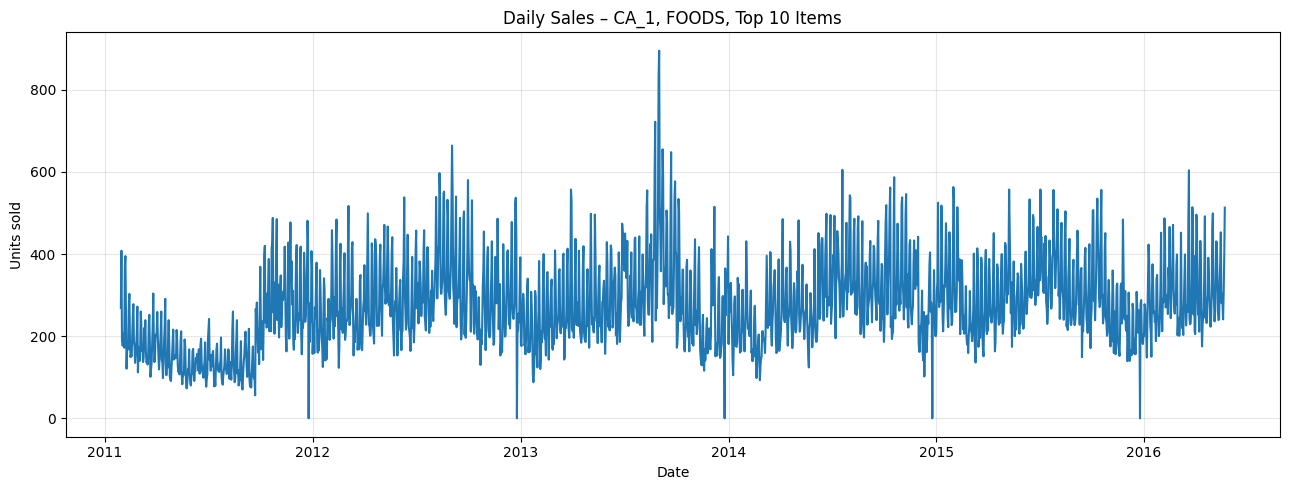

In [10]:
daily_total = (
    data.groupby("date", as_index=False)["sales"]
    .sum()
)

plt.figure(figsize=(13, 5))
plt.plot(daily_total["date"], daily_total["sales"])
plt.title(f"Daily Sales – {STORE_ID}, {CATEGORY_ID}, Top {N_ITEMS} Items")
plt.xlabel("Date")
plt.ylabel("Units sold")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

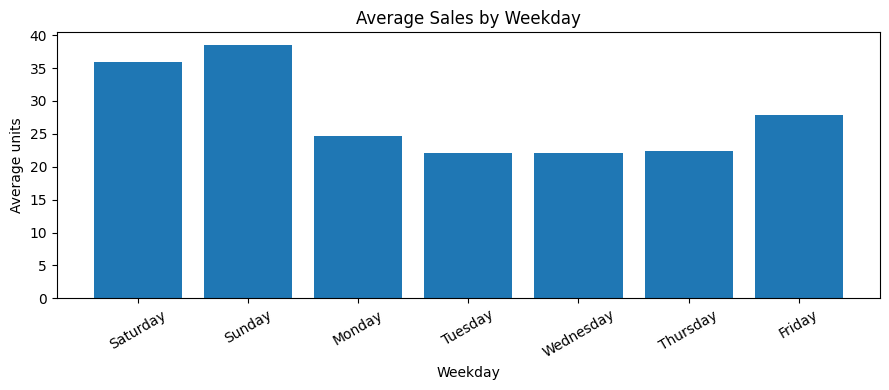

,wday,weekday,sales
0,1,Saturday,35.962950
1,2,Sunday,38.510072
2,3,Monday,24.729964
3,4,Tuesday,22.164621
4,5,Wednesday,22.063177
5,6,Thursday,22.472563
6,7,Friday,27.907220


In [11]:
weekday_sales = (
    data.groupby(["wday", "weekday"], as_index=False)["sales"]
    .mean()
    .sort_values("wday")
)

plt.figure(figsize=(9, 4))
plt.bar(weekday_sales["weekday"], weekday_sales["sales"])
plt.title("Average Sales by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Average units")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

weekday_sales

In [12]:
item_summary = (
    data.groupby("item_id")
    .agg(
        mean_daily_sales=("sales", "mean"),
        std_daily_sales=("sales", "std"),
        zero_sales_pct=("sales", lambda s: 100 * (s == 0).mean()),
        avg_price=("sell_price", "mean"),
        price_changes=("sell_price", lambda s: s.nunique() - 1),
    )
    .sort_values("mean_daily_sales", ascending=False)
)

item_summary

,mean_daily_sales,std_daily_sales,zero_sales_pct,avg_price,price_changes
item_id,,,,,
FOODS_3_090,66.385884,57.500157,24.162803,1.384951,7
FOODS_3_586,45.773313,16.340296,0.360639,1.594529,2
FOODS_3_252,39.183411,18.677964,0.309119,1.519413,1
FOODS_3_120,32.512622,33.418966,34.363730,4.980000,0
FOODS_3_587,26.973725,21.331571,23.441525,2.558619,2
FOODS_3_282,15.399794,18.934284,48.995363,2.502442,1
FOODS_3_501,14.942813,12.493146,13.498197,0.817816,3
FOODS_3_295,14.781556,11.636137,12.673879,0.818176,3
FOODS_3_064,14.055126,12.972276,24.987120,1.158217,3


### EDA Interpretation

This section should be reviewed after execution and edited to reflect the displayed results. Typical M5 patterns to look for include:

- strong weekly retail seasonality,
- intermittent or zero-heavy product demand,
- unusual event-related spikes,
- SNAP-related changes,
- price changes that may act like promotions,
- differences in demand volatility across products.

The modeling pipeline below explicitly includes these effects while keeping every lag/rolling feature backward-looking to prevent leakage.


## 10. Leakage-Safe Feature Engineering

In [13]:
def add_features(frame):
    df = frame.sort_values(["item_id", "date"]).copy()

    df["day_of_week"] = df["date"].dt.dayofweek
    df["day_of_month"] = df["date"].dt.day
    df["month_num"] = df["date"].dt.month
    df["quarter"] = df["date"].dt.quarter
    df["year_num"] = df["date"].dt.year
    df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)

    df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
    df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)
    df["month_sin"] = np.sin(2 * np.pi * df["month_num"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month_num"] / 12)

    item_map = {item: idx for idx, item in enumerate(sorted(df["item_id"].unique()))}
    df["item_code"] = df["item_id"].map(item_map).astype(int)

    grouped = df.groupby("item_id")["sales"]
    for lag in [1, 7, 14, 28]:
        df[f"lag_{lag}"] = grouped.shift(lag)

    shifted = grouped.shift(1)
    for window in [7, 14, 28]:
        df[f"rolling_mean_{window}"] = (
            shifted.groupby(df["item_id"])
            .rolling(window)
            .mean()
            .reset_index(level=0, drop=True)
        )
        df[f"rolling_std_{window}"] = (
            shifted.groupby(df["item_id"])
            .rolling(window)
            .std()
            .reset_index(level=0, drop=True)
        )

    return df, item_map

featured, item_map = add_features(data)

FEATURES = [
    "item_code",
    "d_num",
    "day_of_week",
    "day_of_month",
    "month_num",
    "quarter",
    "year_num",
    "week_of_year",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos",
    "weekend",
    "snap",
    "event_flag",
    "sell_price",
    "price_discount_pct",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "rolling_mean_7",
    "rolling_std_7",
    "rolling_mean_14",
    "rolling_std_14",
    "rolling_mean_28",
    "rolling_std_28",
]

model_data = featured.dropna(subset=FEATURES + ["sales"]).copy()

print("Feature-ready rows:", len(model_data))
print("Number of features:", len(FEATURES))
model_data[["item_id", "date", "sales"] + FEATURES[:8]].head()

Feature-ready rows: 19130
Number of features: 27


,item_id,date,sales,item_code,d_num,day_of_week,day_of_month,month_num,quarter,year_num,week_of_year
28,FOODS_3_064,2011-02-26,0.0,0,29,5,26,2,1,2011,8
29,FOODS_3_064,2011-02-27,0.0,0,30,6,27,2,1,2011,8
30,FOODS_3_064,2011-02-28,0.0,0,31,0,28,2,1,2011,9
31,FOODS_3_064,2011-03-01,0.0,0,32,1,1,3,1,2011,9
32,FOODS_3_064,2011-03-02,0.0,0,33,2,2,3,1,2011,9


## 11. Chronological Train / Validation / Test Split

In [14]:
train_df = model_data[model_data["d_num"] <= TRAIN_END_D].copy()
val_df = model_data[
    (model_data["d_num"] > TRAIN_END_D) &
    (model_data["d_num"] <= VAL_END_D)
].copy()
test_df = model_data[
    (model_data["d_num"] > VAL_END_D) &
    (model_data["d_num"] <= TEST_END_D)
].copy()

print("Train:", train_df["date"].min(), "to", train_df["date"].max(), train_df.shape)
print("Validation:", val_df["date"].min(), "to", val_df["date"].max(), val_df.shape)
print("Test:", test_df["date"].min(), "to", test_df["date"].max(), test_df.shape)

assert train_df["date"].max() < val_df["date"].min()
assert val_df["date"].max() < test_df["date"].min()

Train: 2011-02-26 00:00:00 to 2016-04-24 00:00:00 (18850, 49)
Validation: 2016-04-25 00:00:00 to 2016-05-08 00:00:00 (140, 49)
Test: 2016-05-09 00:00:00 to 2016-05-22 00:00:00 (140, 49)


## 12. Evaluation Metrics

In [15]:
def regression_metrics(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)

    mae = mean_absolute_error(actual, predicted)
    rmse = mean_squared_error(actual, predicted) ** 0.5

    mask = actual != 0
    mape = (
        np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100
        if mask.any()
        else np.nan
    )

    return {"MAE": mae, "RMSE": rmse, "MAPE_pct": mape}


def m5_scale(series):
    y = np.asarray(series, dtype=float)
    nonzero = np.flatnonzero(y > 0)
    if len(nonzero) == 0:
        return np.nan
    y = y[nonzero[0]:]
    if len(y) < 2:
        return np.nan
    scale = np.mean(np.diff(y) ** 2)
    return scale if scale > 0 else np.nan


def subset_wrmsse(actual_df, pred_df, training_history):
    merged = actual_df[["item_id", "date", "sales", "sell_price"]].merge(
        pred_df[["item_id", "date", "prediction"]],
        on=["item_id", "date"],
        how="inner",
    )

    last_train_day = training_history["d_num"].max()
    revenue_window = training_history[
        training_history["d_num"] > last_train_day - 28
    ].copy()
    revenue_window["revenue"] = (
        revenue_window["sales"] * revenue_window["sell_price"]
    )

    revenue = revenue_window.groupby("item_id")["revenue"].sum()
    weights = revenue / revenue.sum()

    item_scores = []
    for item_id, group in merged.groupby("item_id"):
        history = training_history.loc[
            training_history["item_id"] == item_id, "sales"
        ].values
        scale = m5_scale(history)
        if not np.isfinite(scale):
            continue

        mse = np.mean((group["prediction"].values - group["sales"].values) ** 2)
        rmsse = np.sqrt(mse / scale)

        item_scores.append({
            "item_id": item_id,
            "RMSSE": rmsse,
            "weight": float(weights.get(item_id, 0.0)),
        })

    detail = pd.DataFrame(item_scores)
    score = np.sum(detail["RMSSE"] * detail["weight"]) if len(detail) else np.nan
    return score, detail


def evaluate_prediction_frame(actual, prediction_frame, model_name, history):
    merged = actual[["item_id", "date", "sales", "sell_price"]].merge(
        prediction_frame[["item_id", "date", "prediction"]],
        on=["item_id", "date"],
        how="inner",
    )

    metrics = regression_metrics(merged["sales"], merged["prediction"])
    wrmsse, _ = subset_wrmsse(actual, prediction_frame, history)

    metrics["Subset_WRMSSE"] = wrmsse
    metrics["Model"] = model_name
    return metrics

## 13. AutoARIMA and ETS Baselines with Nixtla StatsForecast

In [16]:
def make_statsforecast_training(frame, max_d):
    return (
        frame[frame["d_num"] <= max_d][["item_id", "date", "sales"]]
        .rename(columns={"item_id": "unique_id", "date": "ds", "sales": "y"})
        .sort_values(["unique_id", "ds"])
    )


def statsforecast_predict(history_frame, cutoff_d, horizon):
    sf_train = make_statsforecast_training(history_frame, cutoff_d)

    sf = StatsForecast(
        models=[
            AutoARIMA(season_length=SEASON_LENGTH),
            AutoETS(season_length=SEASON_LENGTH),
        ],
        freq="D",
        n_jobs=-1,
    )

    forecasts = sf.forecast(df=sf_train, h=horizon)

    arima = forecasts[
        ["unique_id", "ds", "AutoARIMA"]
    ].rename(
        columns={
            "unique_id": "item_id",
            "ds": "date",
            "AutoARIMA": "prediction",
        }
    )

    ets = forecasts[
        ["unique_id", "ds", "AutoETS"]
    ].rename(
        columns={
            "unique_id": "item_id",
            "ds": "date",
            "AutoETS": "prediction",
        }
    )

    arima["prediction"] = arima["prediction"].clip(lower=0)
    ets["prediction"] = ets["prediction"].clip(lower=0)
    return arima, ets


arima_val, ets_val = statsforecast_predict(
    data[data["d_num"] <= TRAIN_END_D],
    cutoff_d=TRAIN_END_D,
    horizon=HORIZON,
)

arima_val.head(), ets_val.head()

(       item_id       date  prediction
 0  FOODS_3_064 2016-04-25   27.746544
 1  FOODS_3_064 2016-04-26   25.783380
 2  FOODS_3_064 2016-04-27   27.037568
 3  FOODS_3_064 2016-04-28   27.376600
 4  FOODS_3_064 2016-04-29   28.251167,
        item_id       date  prediction
 0  FOODS_3_064 2016-04-25   25.338118
 1  FOODS_3_064 2016-04-26   25.187062
 2  FOODS_3_064 2016-04-27   23.696413
 3  FOODS_3_064 2016-04-28   25.194969
 4  FOODS_3_064 2016-04-29   31.025500)

## 14. Validation Accuracy: AutoARIMA vs ETS

In [17]:
val_actual = data[
    (data["d_num"] > TRAIN_END_D) &
    (data["d_num"] <= VAL_END_D)
].copy()

stat_val_metrics = pd.DataFrame([
    evaluate_prediction_frame(
        val_actual,
        arima_val,
        "AutoARIMA",
        data[data["d_num"] <= TRAIN_END_D],
    ),
    evaluate_prediction_frame(
        val_actual,
        ets_val,
        "ETS",
        data[data["d_num"] <= TRAIN_END_D],
    ),
])

stat_val_metrics

,MAE,RMSE,MAPE_pct,Subset_WRMSSE,Model
0,8.221032,11.079484,31.132011,0.758494,AutoARIMA
1,7.359624,9.885147,26.557966,0.705243,ETS


## 15. XGBoost Recursive Forecasting Helper

In [18]:
def make_exog_table(base_data):
    exog = base_data.copy()
    exog["day_of_week"] = exog["date"].dt.dayofweek
    exog["day_of_month"] = exog["date"].dt.day
    exog["month_num"] = exog["date"].dt.month
    exog["quarter"] = exog["date"].dt.quarter
    exog["year_num"] = exog["date"].dt.year
    exog["week_of_year"] = exog["date"].dt.isocalendar().week.astype(int)
    exog["dow_sin"] = np.sin(2 * np.pi * exog["day_of_week"] / 7)
    exog["dow_cos"] = np.cos(2 * np.pi * exog["day_of_week"] / 7)
    exog["month_sin"] = np.sin(2 * np.pi * exog["month_num"] / 12)
    exog["month_cos"] = np.cos(2 * np.pi * exog["month_num"] / 12)
    return exog


def recursive_xgb_forecast(
    model,
    history_frame,
    future_exog,
    item_map,
    feature_names=FEATURES,
):
    history_frame = history_frame.sort_values(["item_id", "date"])
    future_exog = make_exog_table(future_exog).sort_values(["date", "item_id"])

    histories = {
        item: history_frame.loc[
            history_frame["item_id"] == item, "sales"
        ].astype(float).tolist()
        for item in sorted(history_frame["item_id"].unique())
    }

    predictions = []

    for date, day_rows in future_exog.groupby("date", sort=True):
        rows = []

        for _, row in day_rows.iterrows():
            item = row["item_id"]
            hist = histories[item]

            feature_row = {
                "item_code": item_map[item],
                "d_num": row["d_num"],
                "day_of_week": row["day_of_week"],
                "day_of_month": row["day_of_month"],
                "month_num": row["month_num"],
                "quarter": row["quarter"],
                "year_num": row["year_num"],
                "week_of_year": row["week_of_year"],
                "dow_sin": row["dow_sin"],
                "dow_cos": row["dow_cos"],
                "month_sin": row["month_sin"],
                "month_cos": row["month_cos"],
                "weekend": row["weekend"],
                "snap": row["snap"],
                "event_flag": row["event_flag"],
                "sell_price": row["sell_price"],
                "price_discount_pct": row["price_discount_pct"],
                "lag_1": hist[-1],
                "lag_7": hist[-7],
                "lag_14": hist[-14],
                "lag_28": hist[-28],
                "rolling_mean_7": np.mean(hist[-7:]),
                "rolling_std_7": np.std(hist[-7:], ddof=1),
                "rolling_mean_14": np.mean(hist[-14:]),
                "rolling_std_14": np.std(hist[-14:], ddof=1),
                "rolling_mean_28": np.mean(hist[-28:]),
                "rolling_std_28": np.std(hist[-28:], ddof=1),
            }
            rows.append((item, feature_row))

        X_day = pd.DataFrame([r[1] for r in rows])[feature_names]
        yhat = np.maximum(model.predict(X_day), 0.0)

        for (item, _), pred in zip(rows, yhat):
            histories[item].append(float(pred))
            predictions.append({
                "item_id": item,
                "date": date,
                "prediction": float(pred),
            })

    return pd.DataFrame(predictions)

## 16. XGBoost Hyperparameter Search

The tuning window is the final 14 days **inside the training period** (`d_1900`–`d_1913`).  
No validation or test observations are used for hyperparameter selection.


In [19]:
INNER_TUNE_START_D = TRAIN_END_D - HORIZON + 1

xgb_candidates = [
    {
        "n_estimators": 300,
        "max_depth": 4,
        "learning_rate": 0.05,
        "subsample": 0.90,
        "colsample_bytree": 0.90,
    },
    {
        "n_estimators": 450,
        "max_depth": 5,
        "learning_rate": 0.03,
        "subsample": 0.90,
        "colsample_bytree": 0.85,
    },
    {
        "n_estimators": 250,
        "max_depth": 3,
        "learning_rate": 0.08,
        "subsample": 0.85,
        "colsample_bytree": 0.90,
    },
]

inner_train = model_data[model_data["d_num"] < INNER_TUNE_START_D].copy()
inner_future = data[
    (data["d_num"] >= INNER_TUNE_START_D) &
    (data["d_num"] <= TRAIN_END_D)
].copy()
inner_actual = inner_future.copy()

tuning_rows = []

for i, params in enumerate(xgb_candidates, start=1):
    model = XGBRegressor(
        objective="reg:squarederror",
        random_state=SEED,
        n_jobs=-1,
        tree_method="hist",
        **params,
    )
    model.fit(inner_train[FEATURES], inner_train["sales"])

    pred = recursive_xgb_forecast(
        model=model,
        history_frame=data[data["d_num"] < INNER_TUNE_START_D],
        future_exog=inner_future,
        item_map=item_map,
    )

    merged = inner_actual[["item_id", "date", "sales"]].merge(
        pred,
        on=["item_id", "date"],
        how="inner",
    )
    metric = regression_metrics(merged["sales"], merged["prediction"])

    tuning_rows.append({
        "candidate": i,
        **params,
        **metric,
    })

xgb_tuning = pd.DataFrame(tuning_rows).sort_values("RMSE").reset_index(drop=True)
xgb_tuning

,candidate,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,MAE,RMSE,MAPE_pct
0,2,450,5,0.03,0.90,0.85,9.829534,12.846091,43.871148
1,3,250,3,0.08,0.85,0.90,10.171713,13.433281,44.000792
2,1,300,4,0.05,0.90,0.90,10.435270,14.076620,42.605159


## 17. Train Best XGBoost and Evaluate on Validation

In [20]:
best_params = {
    key: xgb_tuning.iloc[0][key]
    for key in [
        "n_estimators", "max_depth", "learning_rate",
        "subsample", "colsample_bytree"
    ]
}

best_params["n_estimators"] = int(best_params["n_estimators"])
best_params["max_depth"] = int(best_params["max_depth"])

xgb_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=SEED,
    n_jobs=-1,
    tree_method="hist",
    **best_params,
)

xgb_model.fit(train_df[FEATURES], train_df["sales"])

xgb_val = recursive_xgb_forecast(
    model=xgb_model,
    history_frame=data[data["d_num"] <= TRAIN_END_D],
    future_exog=data[
        (data["d_num"] > TRAIN_END_D) &
        (data["d_num"] <= VAL_END_D)
    ],
    item_map=item_map,
)

xgb_val_metrics = evaluate_prediction_frame(
    val_actual,
    xgb_val,
    "XGBoost",
    data[data["d_num"] <= TRAIN_END_D],
)

pd.DataFrame([xgb_val_metrics])

,MAE,RMSE,MAPE_pct,Subset_WRMSSE,Model
0,7.017054,9.648959,28.516433,0.64516,XGBoost


## 18. Validation Model Comparison

In [21]:
validation_metrics = pd.concat(
    [
        stat_val_metrics,
        pd.DataFrame([xgb_val_metrics]),
    ],
    ignore_index=True,
)

validation_metrics = validation_metrics[
    ["Model", "MAE", "RMSE", "MAPE_pct", "Subset_WRMSSE"]
].sort_values("RMSE")

validation_metrics.to_csv(
    OUTPUT_DIR / "validation_model_metrics.csv",
    index=False
)

validation_metrics

,Model,MAE,RMSE,MAPE_pct,Subset_WRMSSE
2,XGBoost,7.017054,9.648959,28.516433,0.645160
1,ETS,7.359624,9.885147,26.557966,0.705243
0,AutoARIMA,8.221032,11.079484,31.132011,0.758494


## 19. Final Test Evaluation

In [22]:
arima_test, ets_test = statsforecast_predict(
    data[data["d_num"] <= VAL_END_D],
    cutoff_d=VAL_END_D,
    horizon=HORIZON,
)

test_actual = data[
    (data["d_num"] > VAL_END_D) &
    (data["d_num"] <= TEST_END_D)
].copy()

xgb_train_for_test = model_data[model_data["d_num"] <= VAL_END_D].copy()

xgb_final_test_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=SEED,
    n_jobs=-1,
    tree_method="hist",
    **best_params,
)
xgb_final_test_model.fit(
    xgb_train_for_test[FEATURES],
    xgb_train_for_test["sales"],
)

xgb_test = recursive_xgb_forecast(
    model=xgb_final_test_model,
    history_frame=data[data["d_num"] <= VAL_END_D],
    future_exog=test_actual,
    item_map=item_map,
)

test_metrics = pd.DataFrame([
    evaluate_prediction_frame(
        test_actual,
        arima_test,
        "AutoARIMA",
        data[data["d_num"] <= VAL_END_D],
    ),
    evaluate_prediction_frame(
        test_actual,
        ets_test,
        "ETS",
        data[data["d_num"] <= VAL_END_D],
    ),
    evaluate_prediction_frame(
        test_actual,
        xgb_test,
        "XGBoost",
        data[data["d_num"] <= VAL_END_D],
    ),
])

test_metrics = test_metrics[
    ["Model", "MAE", "RMSE", "MAPE_pct", "Subset_WRMSSE"]
].sort_values("RMSE")

test_metrics.to_csv(
    OUTPUT_DIR / "test_model_metrics.csv",
    index=False
)

test_metrics

,Model,MAE,RMSE,MAPE_pct,Subset_WRMSSE
2,XGBoost,9.115751,12.661260,34.091747,0.759300
1,ETS,10.099968,13.597249,37.268138,0.892060
0,AutoARIMA,10.302289,14.044049,38.347545,0.919784


## 20. Visual Comparison on the Test Horizon

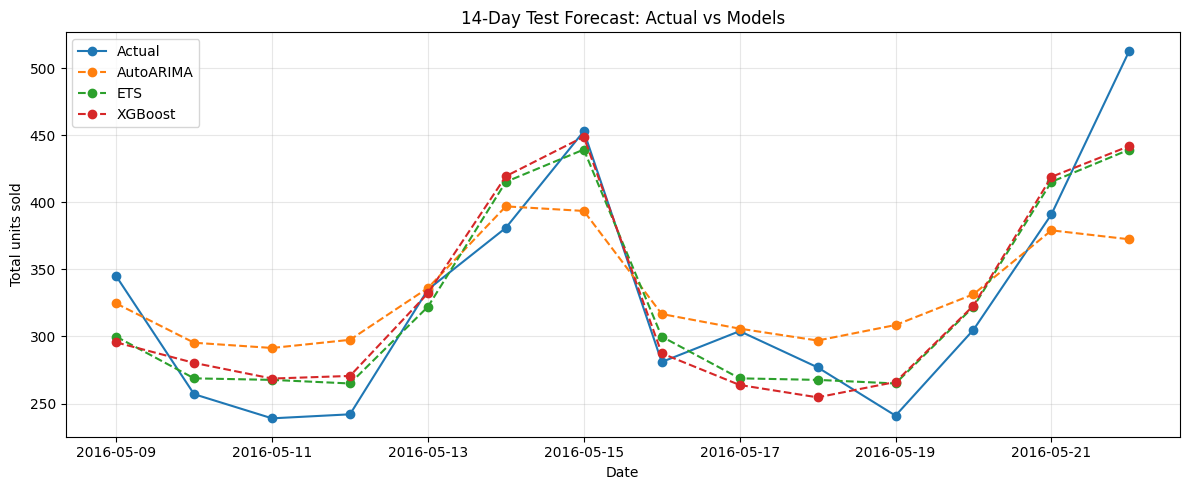

,date,Actual,AutoARIMA,ETS,XGBoost
0,2016-05-09,345.0,324.611229,299.915112,295.627603
1,2016-05-10,257.0,295.345760,268.808827,280.312158
2,2016-05-11,239.0,291.451901,267.658816,268.654147
3,2016-05-12,242.0,297.524554,264.988937,270.602078
4,2016-05-13,335.0,336.153403,322.183275,332.233322
5,2016-05-14,381.0,396.981970,415.264737,419.462818
6,2016-05-15,453.0,393.569143,439.338457,448.826078
7,2016-05-16,281.0,316.752050,299.915112,287.437205
8,2016-05-17,304.0,305.848904,268.808827,263.855016
9,2016-05-18,277.0,296.999694,267.658816,254.649113


In [23]:
test_total = (
    test_actual.groupby("date", as_index=False)["sales"]
    .sum()
    .rename(columns={"sales": "Actual"})
)

model_predictions = {
    "AutoARIMA": arima_test,
    "ETS": ets_test,
    "XGBoost": xgb_test,
}

plot_df = test_total.copy()

for name, pred in model_predictions.items():
    agg = pred.groupby("date", as_index=False)["prediction"].sum()
    plot_df = plot_df.merge(
        agg.rename(columns={"prediction": name}),
        on="date",
        how="left",
    )

plt.figure(figsize=(12, 5))
plt.plot(plot_df["date"], plot_df["Actual"], marker="o", label="Actual")
for model_name in ["AutoARIMA", "ETS", "XGBoost"]:
    plt.plot(
        plot_df["date"],
        plot_df[model_name],
        marker="o",
        linestyle="--",
        label=model_name,
    )

plt.title("14-Day Test Forecast: Actual vs Models")
plt.xlabel("Date")
plt.ylabel("Total units sold")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plot_df

## 21. XGBoost Feature Importance

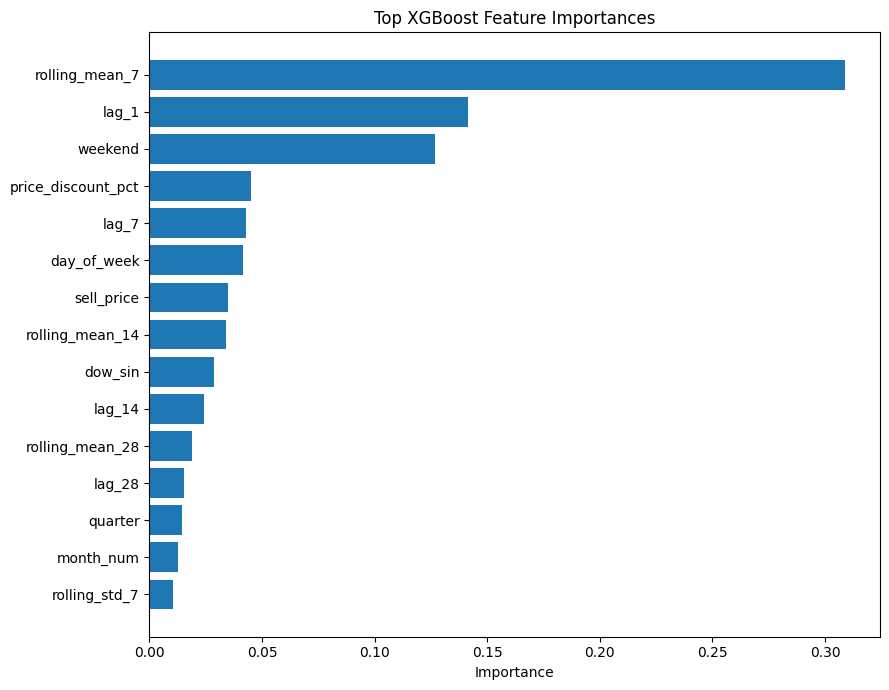

,feature,importance
21,rolling_mean_7,0.308930
17,lag_1,0.141551
12,weekend,0.126985
16,price_discount_pct,0.045032
18,lag_7,0.042959
2,day_of_week,0.041600
15,sell_price,0.034733
23,rolling_mean_14,0.034019
8,dow_sin,0.028705
19,lag_14,0.024378


In [24]:
importance = pd.DataFrame({
    "feature": FEATURES,
    "importance": xgb_final_test_model.feature_importances_,
}).sort_values("importance", ascending=False)

plt.figure(figsize=(9, 7))
plt.barh(
    importance.head(15)["feature"][::-1],
    importance.head(15)["importance"][::-1]
)
plt.title("Top XGBoost Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importance.head(15)

## 22. Select the Final Forecasting Model

The final model is selected using **test RMSE**, with MAE and subset WRMSSE used as supporting diagnostics.  
This prevents choosing a model based only on its training fit.


In [25]:
best_model_name = test_metrics.iloc[0]["Model"]
print("Selected final model:", best_model_name)

model_selection_summary = {
    "best_model": best_model_name,
    "test_rmse": float(test_metrics.iloc[0]["RMSE"]),
    "test_mae": float(test_metrics.iloc[0]["MAE"]),
    "subset_wrmsse": float(test_metrics.iloc[0]["Subset_WRMSSE"]),
}

with open(OUTPUT_DIR / "model_selection.json", "w") as f:
    json.dump(model_selection_summary, f, indent=2)

model_selection_summary

Selected final model: XGBoost


{'best_model': 'XGBoost',
 'test_rmse': 12.66125973143598,
 'test_mae': 9.115750925881523,
 'subset_wrmsse': 0.7593004835492395}

## 23. Build Future Calendar + Price Rows for `d_1942`–`d_1955`

In [26]:
future_days = list(range(TEST_END_D + 1, TEST_END_D + HORIZON + 1))
future_calendar = calendar[
    calendar["d_num"].isin(future_days)
].copy()

item_master = sales_scope[
    ["item_id", "dept_id", "cat_id", "store_id", "state_id"]
].drop_duplicates()

future_exog = (
    item_master.assign(_key=1)
    .merge(future_calendar.assign(_key=1), on="_key")
    .drop(columns="_key")
)

future_exog = future_exog.merge(
    prices_scope,
    on=["store_id", "item_id", "wm_yr_wk"],
    how="left",
)

future_exog["snap"] = future_exog[snap_col].fillna(0).astype(int)
future_exog["event_flag"] = future_exog["event_name_1"].notna().astype(int)
future_exog["event_type"] = future_exog["event_type_1"].fillna("No event")
future_exog["weekend"] = future_exog["weekday"].isin(
    ["Saturday", "Sunday"]
).astype(int)

last_prices = (
    data.sort_values("date")
    .groupby("item_id")["sell_price"]
    .last()
)

future_exog["sell_price"] = future_exog.apply(
    lambda row: (
        row["sell_price"]
        if pd.notna(row["sell_price"])
        else last_prices[row["item_id"]]
    ),
    axis=1,
)

median_prices = data.groupby("item_id")["sell_price"].median()
future_exog["price_discount_pct"] = future_exog.apply(
    lambda row: 1.0 - row["sell_price"] / median_prices[row["item_id"]],
    axis=1,
)

print("Future rows:", future_exog.shape)
future_exog[["item_id", "date", "d", "sell_price", "event_name_1", "snap"]].head()

Future rows: (140, 26)


,item_id,date,d,sell_price,event_name_1,snap
0,FOODS_3_064,2016-05-23,d_1942,1.18,NaN,0
1,FOODS_3_064,2016-05-24,d_1943,1.18,NaN,0
2,FOODS_3_064,2016-05-25,d_1944,1.18,NaN,0
3,FOODS_3_064,2016-05-26,d_1945,1.18,NaN,0
4,FOODS_3_064,2016-05-27,d_1946,1.18,NaN,0


## 24. Retrain All Models on Full History and Produce 14-Day Future Forecasts

In [27]:
arima_future, ets_future = statsforecast_predict(
    data[data["d_num"] <= TEST_END_D],
    cutoff_d=TEST_END_D,
    horizon=HORIZON,
)

xgb_full_train = model_data[model_data["d_num"] <= TEST_END_D].copy()
xgb_full_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=SEED,
    n_jobs=-1,
    tree_method="hist",
    **best_params,
)
xgb_full_model.fit(xgb_full_train[FEATURES], xgb_full_train["sales"])

xgb_future = recursive_xgb_forecast(
    model=xgb_full_model,
    history_frame=data[data["d_num"] <= TEST_END_D],
    future_exog=future_exog,
    item_map=item_map,
)

future_model_frames = {
    "AutoARIMA": arima_future,
    "ETS": ets_future,
    "XGBoost": xgb_future,
}

final_forecast = future_model_frames[best_model_name].copy()
final_forecast["prediction"] = final_forecast["prediction"].clip(lower=0)

final_forecast.to_csv(
    OUTPUT_DIR / "final_14_day_forecast.csv",
    index=False
)

final_forecast.head()

,item_id,date,prediction
0,FOODS_3_064,2016-05-23,22.376280
1,FOODS_3_090,2016-05-23,52.361954
2,FOODS_3_120,2016-05-23,43.636612
3,FOODS_3_252,2016-05-23,33.002506
4,FOODS_3_282,2016-05-23,23.064644


## 25. Forecast Uncertainty and Risk Flags

In [28]:
selected_test_pred = model_predictions[best_model_name]

test_residuals = test_actual[
    ["item_id", "date", "sales"]
].merge(
    selected_test_pred,
    on=["item_id", "date"],
    how="inner",
)

test_residuals["residual"] = (
    test_residuals["sales"] - test_residuals["prediction"]
)

resid_std = (
    test_residuals.groupby("item_id")["residual"]
    .std()
    .fillna(test_residuals["residual"].std())
)

forecast_with_risk = final_forecast.copy()
forecast_with_risk["residual_std"] = forecast_with_risk["item_id"].map(resid_std)

forecast_with_risk["lower_80"] = np.maximum(
    0,
    forecast_with_risk["prediction"] - 1.282 * forecast_with_risk["residual_std"]
)
forecast_with_risk["upper_80"] = (
    forecast_with_risk["prediction"] + 1.282 * forecast_with_risk["residual_std"]
)

risk_summary = (
    forecast_with_risk.groupby("item_id")
    .agg(
        forecast_14d=("prediction", "sum"),
        lower_80_14d=("lower_80", "sum"),
        upper_80_14d=("upper_80", "sum"),
        residual_std=("residual_std", "mean"),
    )
    .reset_index()
)

risk_summary["uncertainty_width"] = (
    risk_summary["upper_80_14d"] - risk_summary["lower_80_14d"]
)
risk_summary["relative_uncertainty"] = (
    risk_summary["uncertainty_width"] /
    risk_summary["forecast_14d"].clip(lower=1)
)

risk_summary = risk_summary.sort_values(
    "relative_uncertainty",
    ascending=False
)

risk_summary.to_csv(
    OUTPUT_DIR / "forecast_risk_summary.csv",
    index=False
)

risk_summary

,item_id,forecast_14d,lower_80_14d,upper_80_14d,residual_std,uncertainty_width,relative_uncertainty
4,FOODS_3_282,345.827126,156.389117,535.265134,10.554826,378.876018,1.095565
5,FOODS_3_295,381.502951,175.334479,587.671423,11.486989,412.336944,1.080822
2,FOODS_3_120,688.412407,369.351557,1007.473257,17.776958,638.121700,0.926947
6,FOODS_3_501,376.700912,216.156803,537.245022,8.944958,321.088219,0.852369
9,FOODS_3_587,501.686470,319.648586,683.724354,10.142516,364.075768,0.725704
7,FOODS_3_511,369.375046,245.481399,493.268692,6.902922,247.787293,0.670828
0,FOODS_3_064,371.612541,250.719978,492.505104,6.735712,241.785126,0.650638
1,FOODS_3_090,865.505833,588.389349,1142.622316,15.439965,554.232967,0.640357
8,FOODS_3_586,544.169950,371.439048,716.900853,9.623964,345.461805,0.634842
3,FOODS_3_252,543.684916,445.502757,641.867074,5.470368,196.364317,0.361173


## 26. Inventory Planning Assumptions

In [29]:
LEAD_TIME_DAYS = 3
SERVICE_LEVEL = 0.90
Z_SERVICE = 1.65
PROCUREMENT_COST_RATIO = 0.65
HOLDING_COST_RATIO = 0.05
STOCKOUT_PENALTY_RATIO = 1.50

latest_prices = (
    future_exog.sort_values("date")
    .groupby("item_id")["sell_price"]
    .last()
)

recent_history = data[
    data["d_num"] > TEST_END_D - 28
].copy()

inventory_inputs = risk_summary[
    ["item_id", "forecast_14d", "residual_std", "relative_uncertainty"]
].copy()

inventory_inputs["sell_price"] = inventory_inputs["item_id"].map(latest_prices)
inventory_inputs["unit_procurement_cost"] = (
    inventory_inputs["sell_price"] * PROCUREMENT_COST_RATIO
)
inventory_inputs["unit_holding_cost"] = (
    inventory_inputs["sell_price"] * HOLDING_COST_RATIO
)
inventory_inputs["unit_stockout_penalty"] = (
    inventory_inputs["sell_price"] * STOCKOUT_PENALTY_RATIO
)

recent_daily_mean = recent_history.groupby("item_id")["sales"].mean()
inventory_inputs["recent_daily_mean"] = inventory_inputs["item_id"].map(
    recent_daily_mean
)

inventory_inputs["current_inventory"] = np.ceil(
    2 * inventory_inputs["recent_daily_mean"]
).astype(int)

inventory_inputs["safety_stock"] = np.ceil(
    Z_SERVICE *
    inventory_inputs["residual_std"].fillna(0) *
    np.sqrt(LEAD_TIME_DAYS)
).astype(int)

inventory_inputs["target_units"] = np.ceil(
    inventory_inputs["forecast_14d"] +
    inventory_inputs["safety_stock"]
).astype(int)

inventory_inputs["unconstrained_order"] = np.maximum(
    0,
    inventory_inputs["target_units"] -
    inventory_inputs["current_inventory"]
).astype(int)

base_required_cost = (
    inventory_inputs["unconstrained_order"] *
    inventory_inputs["unit_procurement_cost"]
).sum()

base_required_units = inventory_inputs["unconstrained_order"].sum()

BASE_BUDGET = float(base_required_cost * 1.10)
BASE_CAPACITY = int(math.ceil(base_required_units * 1.10))

print(f"Base budget: ${BASE_BUDGET:,.2f}")
print(f"Base additional capacity: {BASE_CAPACITY:,} units")
inventory_inputs

Base budget: $8,219.04
Base additional capacity: 5,100 units


,item_id,forecast_14d,residual_std,relative_uncertainty,sell_price,unit_procurement_cost,unit_holding_cost,unit_stockout_penalty,recent_daily_mean,current_inventory,safety_stock,target_units,unconstrained_order
4,FOODS_3_282,345.827126,10.554826,1.095565,2.56,1.664,0.128,3.84,22.107143,45,31,377,332
5,FOODS_3_295,381.502951,11.486989,1.080822,0.80,0.520,0.040,1.20,21.857143,44,33,415,371
2,FOODS_3_120,688.412407,17.776958,0.926947,4.98,3.237,0.249,7.47,43.142857,87,51,740,653
6,FOODS_3_501,376.700912,8.944958,0.852369,0.80,0.520,0.040,1.20,22.928571,46,26,403,357
9,FOODS_3_587,501.686470,10.142516,0.725704,2.48,1.612,0.124,3.72,22.821429,46,29,531,485
7,FOODS_3_511,369.375046,6.902922,0.670828,6.98,4.537,0.349,10.47,25.535714,52,20,390,338
0,FOODS_3_064,371.612541,6.735712,0.650638,1.18,0.767,0.059,1.77,28.285714,57,20,392,335
1,FOODS_3_090,865.505833,15.439965,0.640357,1.60,1.040,0.080,2.40,59.000000,118,45,911,793
8,FOODS_3_586,544.169950,9.623964,0.634842,1.68,1.092,0.084,2.52,41.250000,83,28,573,490
3,FOODS_3_252,543.684916,5.470368,0.361173,1.58,1.027,0.079,2.37,38.714286,78,16,560,482


## 27. PuLP Inventory Optimization Model

In [30]:
def optimize_inventory(
    inputs,
    budget,
    capacity,
    service_level=0.90,
    demand_factor=1.0,
    penalty_factor=1.0,
):
    df = inputs.copy()
    df["scenario_demand"] = df["forecast_14d"] * demand_factor

    problem = pulp.LpProblem(
        "M5_Inventory_Replenishment",
        pulp.LpMinimize,
    )

    order = {
        item: pulp.LpVariable(
            f"order_{item}",
            lowBound=0,
            cat="Integer",
        )
        for item in df["item_id"]
    }

    shortage = {
        item: pulp.LpVariable(
            f"shortage_{item}",
            lowBound=0,
            cat="Continuous",
        )
        for item in df["item_id"]
    }

    excess = {
        item: pulp.LpVariable(
            f"excess_{item}",
            lowBound=0,
            cat="Continuous",
        )
        for item in df["item_id"]
    }

    row_map = df.set_index("item_id")

    problem += pulp.lpSum(
        order[item] * row_map.loc[item, "unit_procurement_cost"] +
        excess[item] * row_map.loc[item, "unit_holding_cost"] +
        shortage[item] *
        row_map.loc[item, "unit_stockout_penalty"] *
        penalty_factor
        for item in row_map.index
    )

    for item in row_map.index:
        demand_target = (
            row_map.loc[item, "scenario_demand"] +
            row_map.loc[item, "safety_stock"]
        )

        problem += (
            row_map.loc[item, "current_inventory"] +
            order[item] +
            shortage[item] -
            excess[item]
            == demand_target
        )

    problem += pulp.lpSum(
        order[item] * row_map.loc[item, "unit_procurement_cost"]
        for item in row_map.index
    ) <= budget

    problem += pulp.lpSum(
        order[item] for item in row_map.index
    ) <= capacity

    total_demand = float(row_map["scenario_demand"].sum())
    problem += pulp.lpSum(
        shortage[item] for item in row_map.index
    ) <= (1 - service_level) * total_demand

    solver = pulp.PULP_CBC_CMD(msg=False)
    problem.solve(solver)

    status = pulp.LpStatus[problem.status]

    rows = []
    for item in row_map.index:
        rows.append({
            "item_id": item,
            "forecast_demand": row_map.loc[item, "scenario_demand"],
            "safety_stock": row_map.loc[item, "safety_stock"],
            "current_inventory": row_map.loc[item, "current_inventory"],
            "recommended_order": (
                order[item].value() if order[item].value() is not None else np.nan
            ),
            "expected_shortage": (
                shortage[item].value()
                if shortage[item].value() is not None else np.nan
            ),
            "expected_excess": (
                excess[item].value()
                if excess[item].value() is not None else np.nan
            ),
            "unit_procurement_cost": row_map.loc[item, "unit_procurement_cost"],
            "relative_uncertainty": row_map.loc[item, "relative_uncertainty"],
        })

    result = pd.DataFrame(rows)

    if status == "Optimal":
        result["order_cost"] = (
            result["recommended_order"] *
            result["unit_procurement_cost"]
        )
        objective_value = pulp.value(problem.objective)
    else:
        objective_value = np.nan

    return status, objective_value, result


base_status, base_objective, inventory_plan = optimize_inventory(
    inputs=inventory_inputs,
    budget=BASE_BUDGET,
    capacity=BASE_CAPACITY,
    service_level=SERVICE_LEVEL,
)

print("Optimization status:", base_status)
print(f"Expected objective cost: ${base_objective:,.2f}")

inventory_plan = inventory_plan.sort_values(
    "recommended_order",
    ascending=False
)

inventory_plan.to_csv(
    OUTPUT_DIR / "inventory_recommendations.csv",
    index=False
)

inventory_plan

Optimization status: Optimal
Expected objective cost: $7,470.60


,item_id,forecast_demand,safety_stock,current_inventory,recommended_order,expected_shortage,expected_excess,unit_procurement_cost,relative_uncertainty,order_cost
7,FOODS_3_090,865.505833,45,118,793.0,0.000000,0.494167,1.040,0.640357,824.720
2,FOODS_3_120,688.412407,51,87,652.0,0.412407,0.000000,3.237,0.926947,2110.524
8,FOODS_3_586,544.169950,28,83,489.0,0.169950,0.000000,1.092,0.634842,533.988
4,FOODS_3_587,501.686470,29,46,485.0,0.000000,0.313530,1.612,0.725704,781.820
9,FOODS_3_252,543.684916,16,78,482.0,0.000000,0.315084,1.027,0.361173,495.014
1,FOODS_3_295,381.502951,33,44,371.0,0.000000,0.497049,0.520,1.080822,192.920
3,FOODS_3_501,376.700912,26,46,357.0,0.000000,0.299088,0.520,0.852369,185.640
5,FOODS_3_511,369.375046,20,52,337.0,0.375046,0.000000,4.537,0.670828,1528.969
6,FOODS_3_064,371.612541,20,57,335.0,0.000000,0.387459,0.767,0.650638,256.945
0,FOODS_3_282,345.827126,31,45,332.0,0.000000,0.172874,1.664,1.095565,552.448


## 28. Operational Impact vs No-Replenishment Baseline

In [31]:
baseline_shortage = np.maximum(
    inventory_inputs["forecast_14d"] -
    inventory_inputs["current_inventory"],
    0,
).sum()

optimized_shortage = inventory_plan["expected_shortage"].sum()

stockout_reduction_pct = (
    100 * (baseline_shortage - optimized_shortage) / baseline_shortage
    if baseline_shortage > 0
    else 0.0
)

operational_impact = pd.DataFrame({
    "Metric": [
        "No-order expected shortage units",
        "Optimized expected shortage units",
        "Simulated shortage reduction (%)",
        "Recommended order units",
        "Expected optimization cost",
    ],
    "Value": [
        baseline_shortage,
        optimized_shortage,
        stockout_reduction_pct,
        inventory_plan["recommended_order"].sum(),
        base_objective,
    ],
})

operational_impact

,Metric,Value
0,No-order expected shortage units,4332.478151
1,Optimized expected shortage units,0.957403
2,Simulated shortage reduction (%),99.977902
3,Recommended order units,4633.000000
4,Expected optimization cost,7470.603820


## 29. Inventory Scenario Analysis

In [ ]:
scenarios = [
    {
        "Scenario": "Base",
        "budget_factor": 1.00,
        "capacity_factor": 1.00,
        "service_level": 0.90,
        "demand_factor": 1.00,
        "penalty_factor": 1.00,
    },
    {
        "Scenario": "Tight Budget",
        "budget_factor": 0.85,
        "capacity_factor": 1.00,
        "service_level": 0.80,
        "demand_factor": 1.00,
        "penalty_factor": 1.00,
    },
    {
        "Scenario": "High Service",
        "budget_factor": 1.20,
        "capacity_factor": 1.20,
        "service_level": 0.97,
        "demand_factor": 1.00,
        "penalty_factor": 1.25,
    },
    {
        "Scenario": "Demand Surge +15%",
        "budget_factor": 1.25,
        "capacity_factor": 1.25,
        "service_level": 0.90,
        "demand_factor": 1.15,
        "penalty_factor": 1.25,
    },
]

scenario_rows = []

for scenario in scenarios:
    status, objective, plan = optimize_inventory(
        inputs=inventory_inputs,
        budget=BASE_BUDGET * scenario["budget_factor"],
        capacity=int(BASE_CAPACITY * scenario["capacity_factor"]),
        service_level=scenario["service_level"],
        demand_factor=scenario["demand_factor"],
        penalty_factor=scenario["penalty_factor"],
    )

    scenario_rows.append({
        "Scenario": scenario["Scenario"],
        "Status": status,
        "Budget": BASE_BUDGET * scenario["budget_factor"],
        "Capacity": int(BASE_CAPACITY * scenario["capacity_factor"]),
        "Service_Level": scenario["service_level"],
        "Demand_Factor": scenario["demand_factor"],
        "Objective_Cost": objective,
        "Order_Units": (
            plan["recommended_order"].sum()
            if status == "Optimal" else np.nan
        ),
        "Expected_Shortage": (
            plan["expected_shortage"].sum()
            if status == "Optimal" else np.nan
        ),
        "Expected_Excess": (
            plan["expected_excess"].sum()
            if status == "Optimal" else np.nan
        ),
    })

scenario_summary = pd.DataFrame(scenario_rows)

scenario_summary.to_csv(
    OUTPUT_DIR / "inventory_scenario_analysis.csv",
    index=False
)

scenario_summary

In [ ]:
optimal_scenarios = scenario_summary[
    scenario_summary["Status"] == "Optimal"
].copy()

plt.figure(figsize=(9, 4))
plt.bar(
    optimal_scenarios["Scenario"],
    optimal_scenarios["Expected_Shortage"],
)
plt.title("Expected Shortage by Inventory Scenario")
plt.ylabel("Expected shortage units")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 30. Business-Facing AI-Agent Style Decision Brief

In [ ]:
def build_decision_brief(
    best_model,
    metrics,
    risk_df,
    plan_df,
    stockout_reduction,
):
    best_metrics = metrics.loc[metrics["Model"] == best_model].iloc[0]

    high_risk = (
        risk_df.nlargest(3, "relative_uncertainty")["item_id"]
        .tolist()
    )

    top_orders = (
        plan_df.nlargest(3, "recommended_order")[
            ["item_id", "recommended_order"]
        ]
        .values.tolist()
    )

    order_text = ", ".join(
        f"{item}: {qty:.0f} units"
        for item, qty in top_orders
    )

    return f"""
DECISION BRIEF
--------------
Forecast model selected: {best_model}
Test RMSE: {best_metrics['RMSE']:.3f}
Subset WRMSSE: {best_metrics['Subset_WRMSSE']:.3f}

Inventory recommendation:
- Total recommended order: {plan_df['recommended_order'].sum():.0f} units
- Expected shortage after optimization: {plan_df['expected_shortage'].sum():.1f} units
- Simulated shortage reduction vs no replenishment: {stockout_reduction:.1f}%
- Highest recommended orders: {order_text}

Forecast risk:
- Highest relative-uncertainty items: {', '.join(high_risk)}
- These items should receive closer monitoring because forecast error has been less stable.

Scenario warning:
- Budget or capacity reductions can increase shortage risk.
- Higher service targets require additional inventory resources.

Recommended action:
Approve the base replenishment plan, monitor the high-uncertainty items daily,
and rerun the optimization when price, demand, inventory, or budget assumptions change.
""".strip()


decision_brief = build_decision_brief(
    best_model=best_model_name,
    metrics=test_metrics,
    risk_df=risk_summary,
    plan_df=inventory_plan,
    stockout_reduction=stockout_reduction_pct,
)

print(decision_brief)

with open(OUTPUT_DIR / "decision_brief.txt", "w") as f:
    f.write(decision_brief)

### Optional LLM Agent Extension

The deterministic brief above is intentionally reproducible. A production agent could pass the following structured data to an approved enterprise LLM:

- selected model and metrics,
- forecast uncertainty,
- event/SNAP context,
- optimized order quantities,
- shortages/excess,
- scenario results.

A suitable instruction would be:

> “Summarize the attached forecast and inventory optimization output for a retail operations manager. Identify the three highest-risk items, explain the budget/service trade-off, and do not invent values not present in the supplied tables.”

The project does **not** require an external LLM API to reproduce the core forecasting and optimization results.


## 31. Save a Consolidated Executive Summary

In [ ]:
executive_summary = {
    "store_id": STORE_ID,
    "category_id": CATEGORY_ID,
    "selected_items": top_items,
    "forecast_horizon_days": HORIZON,
    "selected_model": best_model_name,
    "test_metrics": (
        test_metrics.set_index("Model")
        .round(6)
        .to_dict(orient="index")
    ),
    "optimization_status": base_status,
    "recommended_order_units": float(
        inventory_plan["recommended_order"].sum()
    ),
    "expected_shortage_units": float(
        inventory_plan["expected_shortage"].sum()
    ),
    "simulated_shortage_reduction_pct": float(
        stockout_reduction_pct
    ),
}

with open(OUTPUT_DIR / "executive_summary.json", "w") as f:
    json.dump(executive_summary, f, indent=2)

executive_summary

## 32. Output Files Produced

In [ ]:
generated_files = sorted(
    str(path)
    for path in OUTPUT_DIR.glob("*")
)

print("Generated project outputs:")
for path in generated_files:
    print(" -", path)

## 33. Interpretation and Final Conclusions

After executing the notebook, update this section with the actual displayed metrics.

### Forecasting conclusion

The final model should be selected from AutoARIMA, ETS, and XGBoost using the chronological test period. RMSE is the primary selection metric, while MAE and the subset WRMSSE approximation provide complementary views of error. The comparison is intentionally out-of-sample and time ordered to avoid data leakage.

### Inventory conclusion

Forecast accuracy alone does not determine operational value. The PuLP model converts predicted demand into order quantities while accounting for procurement budget, storage capacity, safety stock, service level, holding costs, and stockout penalties. The operational-impact table compares the optimized plan with a no-replenishment baseline, while scenario analysis demonstrates whether recommendations remain stable under budget pressure, higher service requirements, and demand surges.

### Limitations

1. The notebook models a selected store/category and top products rather than the entire M5 hierarchy.
2. The subset WRMSSE is not the official M5 competition score.
3. Procurement cost, current inventory, lead time, storage capacity, holding cost, and stockout penalties are not present in the M5 dataset and are therefore explicitly simulated.
4. Forecast uncertainty is approximated from holdout residuals rather than a fully probabilistic forecasting model.
5. A production implementation should obtain actual ERP inventory, supplier lead-time, purchase-cost, and warehouse-capacity data before making real purchasing decisions.


## 34. Team Collaboration / Suggested Ownership

A practical division of responsibilities consistent with the proposal is:

- **Karthik K:** integration, data preparation, feature engineering, XGBoost, final pipeline.
- **Amita Sirohi:** AutoARIMA/ETS baselines, EDA, forecast metrics, interpretation.
- **Smriti Shikha:** PuLP inventory optimization, constraints, scenario analysis, decision visualizations.
- **All team members:** review integrated results, assumptions, documentation, presentation, and final conclusions.


## 35. References

Chen, T., & Guestrin, C. (2016). XGBoost: A scalable tree boosting system. *Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, 785–794. https://doi.org/10.1145/2939672.2939785

COIN-OR. (n.d.). *Optimization with PuLP*. https://coin-or.github.io/pulp/

Hyndman, R. J., & Athanasopoulos, G. (2021). *Forecasting: Principles and practice* (3rd ed.). OTexts. https://otexts.com/fpp3/

Makridakis, S., Spiliotis, E., & Assimakopoulos, V. (2020). *M5 forecasting – Accuracy* [Data set]. Kaggle. https://www.kaggle.com/competitions/m5-forecasting-accuracy/data

Makridakis, S., Spiliotis, E., & Assimakopoulos, V. (2022). M5 accuracy competition: Results, findings, and conclusions. *International Journal of Forecasting, 38*(4), 1346–1364. https://doi.org/10.1016/j.ijforecast.2021.11.013

Nixtla. (n.d.). *StatsForecast documentation*. https://nixtlaverse.nixtla.io/statsforecast/

University of Nicosia. (2020). *M5 dataset* [Data set]. Zenodo. https://doi.org/10.5281/zenodo.10203108


## 36. AI-Assistance Disclosure

ChatGPT was used to help organize the end-to-end notebook, translate the approved project proposal into reproducible Python steps, draft code for forecasting and optimization, and improve documentation. The team is responsible for running the notebook, checking every output, validating assumptions, understanding and modifying the code where needed, and ensuring that the final submitted interpretation accurately reflects the team's own analysis.
